In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from evo.dataset import CherriesDataset

/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [3]:
data_dir = Path("/scratch/users/milind_jagota/bcr/data/heavylight/peint/edges_joint")
family = "d1"
data_path = data_dir / f"{family}.txt"
assert data_path.exists(), f"Data file {data_path} does not exist."

In [5]:
dataset = CherriesDataset(data_path, cache_indices=False)
timesteps = [dataset[i][2] for i in range(len(dataset))]

In [6]:
from collections import Counter
same_length_seqs = [len(x) == len(y) for x, y, _ in dataset]
print(Counter(same_length_seqs))

Counter({True: 128476})


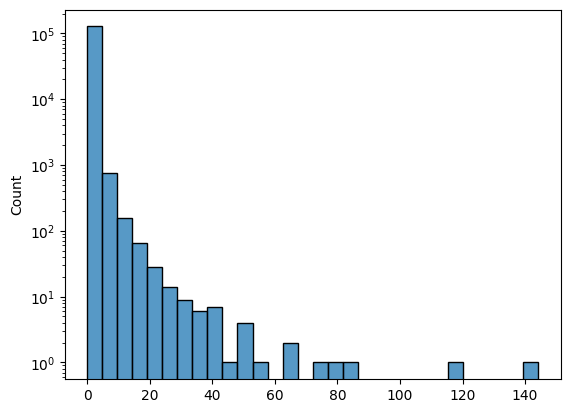

In [7]:
fig, ax = plt.subplots()
sns.histplot(data=timesteps, bins=30, ax=ax)
ax.set_yscale("log")
plt.show()

In [12]:
# Take a look at the hamming distance distribution between parent child pairs
dists = []
for i in range(len(dataset)):
    x, y, _ = dataset[i]
    if len(x) == len(y):
        dists.append(np.sum(x != y))

print(Counter(dists))

Counter({1: 128476})


In [ ]:
df = pd.read_csv("../data/wyatt/wyatt-10x-1p5m_fs-all-prank_paired-merged_pcp_2025-06-24.csv")
df = df[df['sample_id'] == family]
timesteps = df['branch_length']
# timesteps = df['distance']

In [ ]:
fig, ax = plt.subplots()
sns.histplot(data=timesteps, bins=30, ax=ax)
ax.set_yscale("log")
plt.show()